In [1]:
import sys

print(sys.executable)

import pandas as pd

print(pd.__version__)

c:\Users\Anupama Narayan\Desktop\NeuralRetail\venv\Scripts\python.exe
2.3.0


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import timedelta

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (12,6)

In [8]:
df = pd.read_csv("online_retail_II.csv")
print(df.shape)

df.head()
df.info()
df.describe(include='all')

(525461, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      525461 non-null  object 
 1   StockCode    525461 non-null  object 
 2   Description  522533 non-null  object 
 3   Quantity     525461 non-null  int64  
 4   InvoiceDate  525461 non-null  object 
 5   Price        525461 non-null  float64
 6   Customer ID  417534 non-null  float64
 7   Country      525461 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 32.1+ MB


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,525461,525461,522533,525461.000000,525461,525461.000000,417534.000000,525461
unique,28816,4632,4681,NaN,25296,NaN,NaN,40
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,12/06/2010 16:57:00,NaN,NaN,United Kingdom
freq,675,3516,3549,NaN,675,NaN,NaN,485852
mean,NaN,NaN,NaN,10.337667,NaN,4.688834,15360.645478,NaN
std,NaN,NaN,NaN,107.424110,NaN,146.126914,1680.811316,NaN
min,NaN,NaN,NaN,-9600.000000,NaN,-53594.360000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,NaN,1.250000,13983.000000,NaN
50%,NaN,NaN,NaN,3.000000,NaN,2.100000,15311.000000,NaN
75%,NaN,NaN,NaN,10.000000,NaN,4.210000,16799.000000,NaN


In [9]:
df.columns = [
    "Invoice",
    "StockCode",
    "Description",
    "Quantity",
    "InvoiceDate",
    "Price",
    "CustomerID",
    "Country"
] #renaming the columns

In [10]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

print(missing) #removing dupes, nulls, invalid price etc
print("Duplicates:", df.duplicated().sum()) 
df = df.drop_duplicates()
df = df.dropna(subset=["CustomerID"])
df = df[df["Price"] > 0]

CustomerID     107927
Description      2928
StockCode           0
Invoice             0
Quantity            0
InvoiceDate         0
Price               0
Country             0
dtype: int64
Duplicates: 6865


In [11]:
df["Revenue"] = (
    df["Quantity"] *
    df["Price"]
)

In [12]:
df["Year"] = df["InvoiceDate"].dt.year

df["Month"] = df["InvoiceDate"].dt.month

df["MonthName"] = df["InvoiceDate"].dt.month_name()

df["Quarter"] = df["InvoiceDate"].dt.quarter

df["Week"] = df["InvoiceDate"].dt.isocalendar().week

df["Day"] = df["InvoiceDate"].dt.day

df["Weekday"] = df["InvoiceDate"].dt.day_name()

df["Hour"] = df["InvoiceDate"].dt.hour

df["Weekend"] = (
    df["InvoiceDate"]
    .dt.weekday
    .isin([5,6])
)

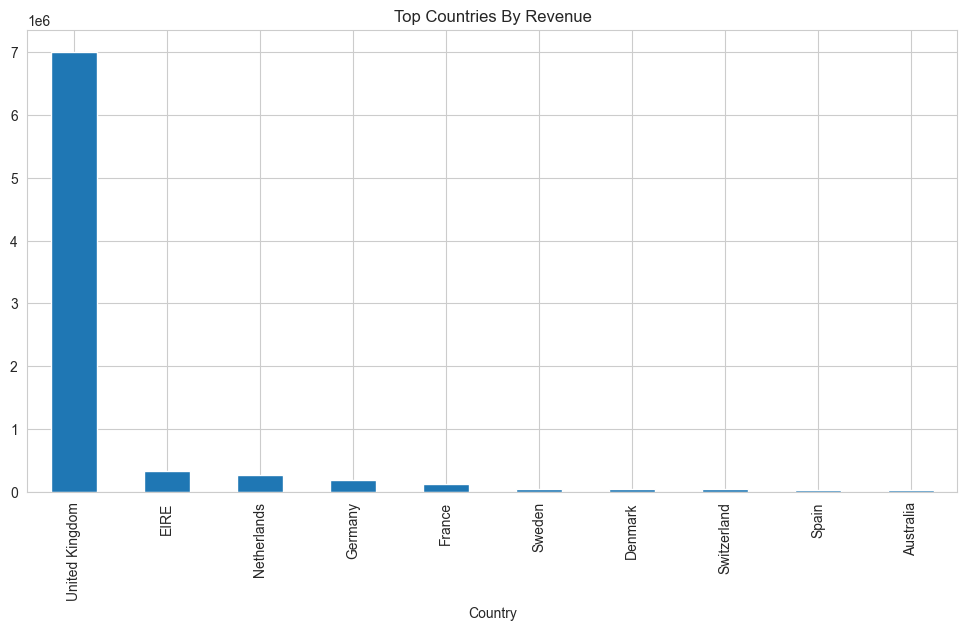

In [13]:
country_revenue = (
    df.groupby("Country")
      ["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

country_revenue.head(20)
country_revenue.head(10).plot(
    kind="bar"
)

plt.title("Top Countries By Revenue")

plt.show() #coountry analysis

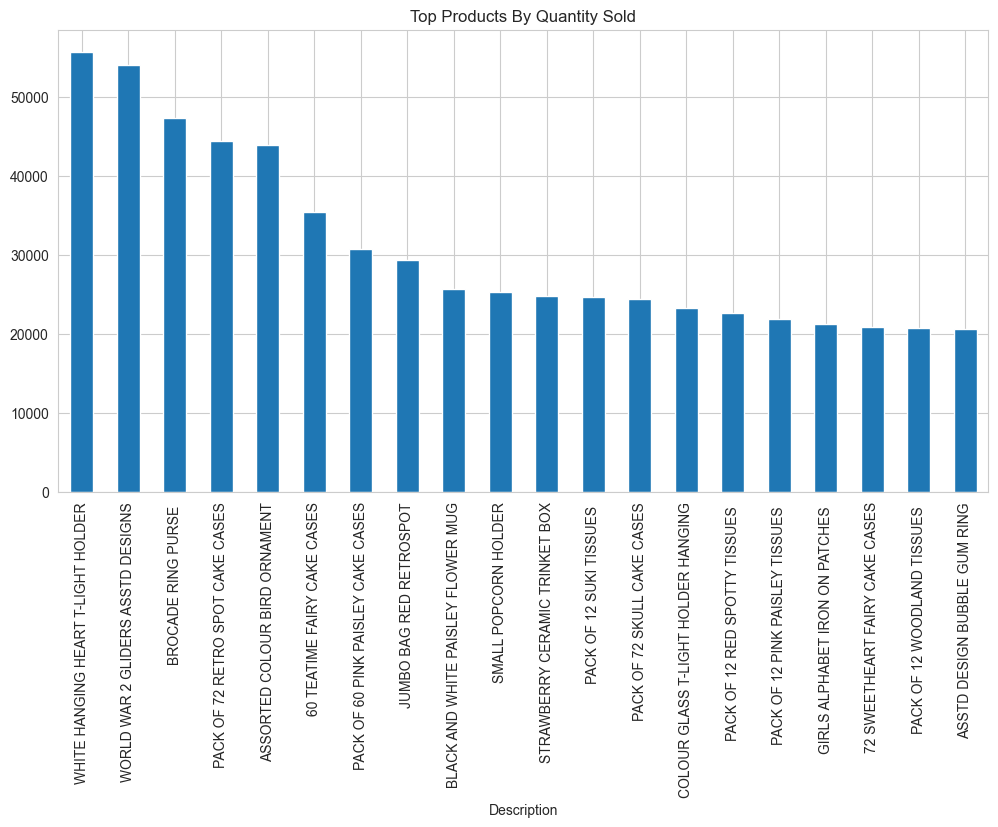

In [14]:
top_products = (
    df.groupby("Description")
      ["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(20)
)

top_products
top_products.plot(
    kind="bar"
)

plt.title(
    "Top Products By Quantity Sold"
)

plt.show() #product analysis

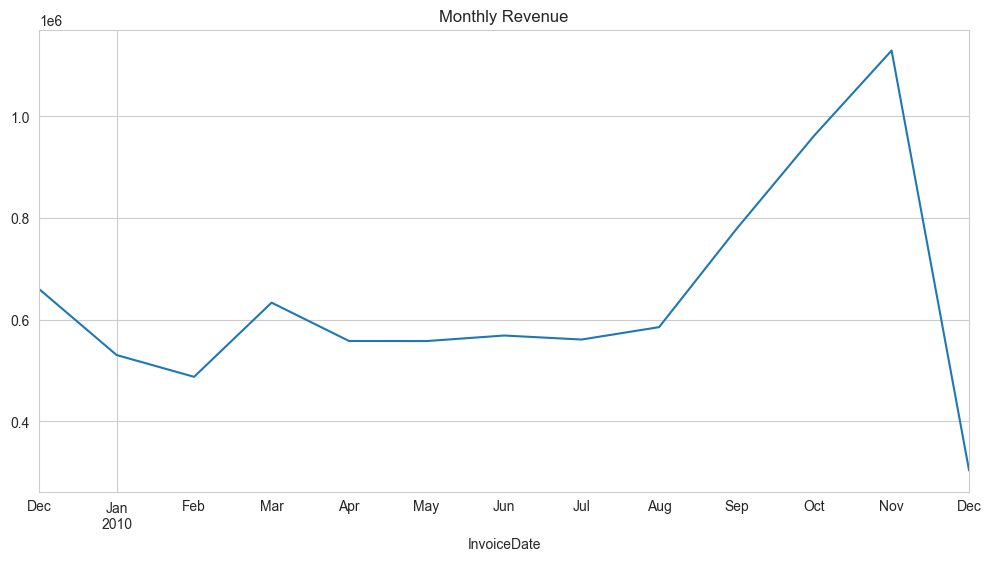

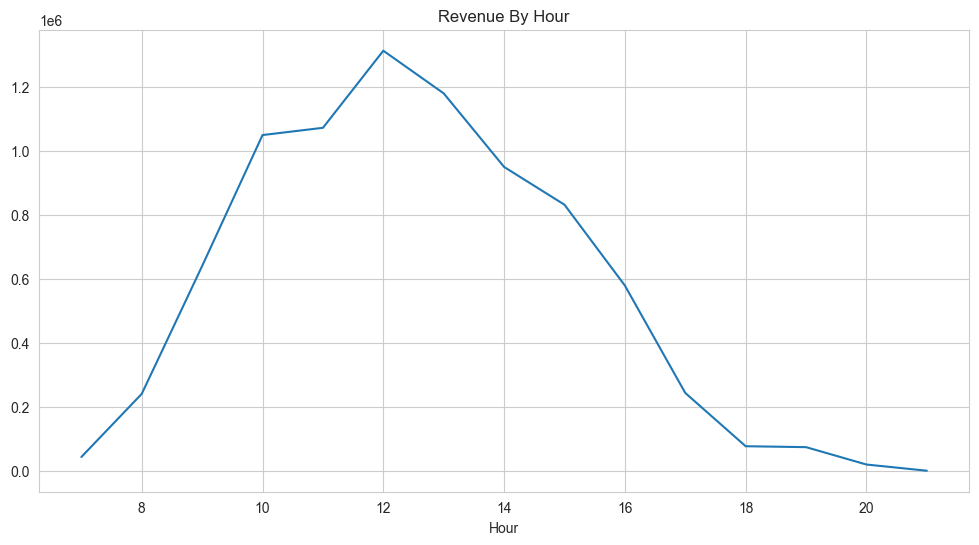

In [15]:
monthly_revenue = (
    df.groupby(
        df["InvoiceDate"].dt.to_period("M")
    )["Revenue"]
    .sum()
)
monthly_revenue.plot()

plt.title(
    "Monthly Revenue"
)

plt.show() #monthly revenue trend

hourly_revenue = ( #revenue trend, hourly
    df.groupby("Hour")
      ["Revenue"]
      .sum()
)
hourly_revenue.plot()

plt.title(
    "Revenue By Hour"
)

plt.show()

In [16]:
daily_sales = (
    df.groupby(
        df["InvoiceDate"].dt.date
    )["Revenue"]
    .sum()
    .reset_index()
)

daily_sales.columns = [
    "Date",
    "Revenue"
] #daily sales trend

In [17]:
daily_sales["lag_1"] = (
    daily_sales["Revenue"]
    .shift(1)
) #lag features

daily_sales["lag_7"] = (
    daily_sales["Revenue"]
    .shift(7)
)

daily_sales["lag_14"] = (
    daily_sales["Revenue"]
    .shift(14)
)

daily_sales["lag_30"] = (
    daily_sales["Revenue"]
    .shift(30)
)

In [19]:
daily_sales["rolling_7"] = (
    daily_sales["Revenue"]
    .rolling(7)
    .mean() #rolling averages
)

daily_sales["rolling_14"] = (
    daily_sales["Revenue"]
    .rolling(14)
    .mean()
)

daily_sales["rolling_30"] = (
    daily_sales["Revenue"]
    .rolling(30)
    .mean()
)

In [20]:
daily_sales["rolling_std_7"] = (
    daily_sales["Revenue"]
    .rolling(7)
    .std()
)

daily_sales["rolling_std_30"] = (
    daily_sales["Revenue"]
    .rolling(30)
    .std()
) #rolling std

In [21]:
snapshot_date = (
    df["InvoiceDate"].max()
    + timedelta(days=1)
) #rfm

recency = (
    df.groupby("CustomerID")
      ["InvoiceDate"]
      .max()
      .reset_index()
)

recency["Recency"] = (
    snapshot_date
    - recency["InvoiceDate"]
).dt.days

frequency = (
    df.groupby("CustomerID")
      ["Invoice"]
      .nunique()
      .reset_index()
)

frequency.columns = [
    "CustomerID",
    "Frequency"
]
monetary = (
    df.groupby("CustomerID")
      ["Revenue"]
      .sum()
      .reset_index()
)

monetary.columns = [
    "CustomerID",
    "Monetary"
]

In [22]:
customer_features = (
    recency[
        ["CustomerID","Recency"]
    ]
    .merge(
        frequency,
        on="CustomerID"
    )
    .merge(
        monetary,
        on="CustomerID"
    )
)

In [23]:
aov = (
    df.groupby("CustomerID")  #average order value
      ["Revenue"]
      .mean()
      .reset_index()
)

aov.columns = [
    "CustomerID",
    "AvgOrderValue"
]
unique_products = (
    df.groupby("CustomerID")
      ["StockCode"]
      .nunique()
      .reset_index()
)

unique_products.columns = [
    "CustomerID",
    "UniqueProducts"
]
quantity_total = (
    df.groupby("CustomerID") #total quantity purchased
      ["Quantity"]
      .sum()
      .reset_index()
)

quantity_total.columns = [
    "CustomerID",
    "TotalQuantity"
]

In [24]:
clv = (
    df.groupby("CustomerID") #customer lifetime revenue, most impp
      ["Revenue"]
      .sum()
      .reset_index()
)

clv.columns = [
    "CustomerID",
    "CLV"
]

In [25]:
customer_features = ( #just merging features
    customer_features
    .merge(aov,on="CustomerID")
    .merge(unique_products,on="CustomerID")
    .merge(quantity_total,on="CustomerID")
    .merge(clv,on="CustomerID")
)

In [26]:
customer_features["Churn"] = (  #for the churn feature in future
    customer_features["Recency"] > 90 
).astype(int)

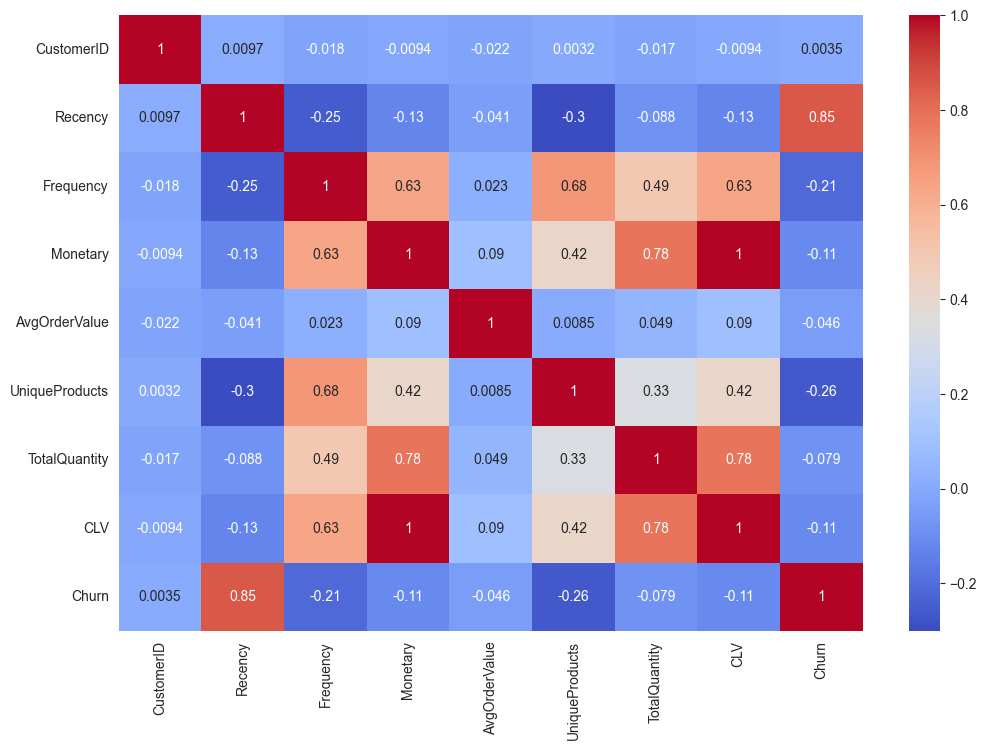

In [27]:
plt.figure(
    figsize=(12,8)
)

sns.heatmap(
    customer_features.corr(
        numeric_only=True
    ),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [28]:
#datasets, gonna be saved acc requirements
df.to_csv(
    "online_retail_cleaned.csv",
    index=False
)

customer_features.to_csv( 
    "customer_features.csv",
    index=False
)

daily_sales.to_csv(  #for forecasting
    "daily_sales_features.csv",
    index=False
)